# Rendu 2 — Aide Publique au Développement française
## Rapport de modélisation

**Dataset d'entrée** : `aide-publique-au-developpement_clean.csv` produit par le Rendu 1
**Variable cible** : `log_engagements` = log(1 + Engagements K EUR) — régression
**Objectif** : benchmarker plusieurs modèles avec Target Encoding, interpréter le meilleur

> **📋 Organisation du projet** — ce projet est structuré en deux notebooks :
> - **`Rendu1_APD_analyse.ipynb`** — exploration, visualisation, pre-processing du dataset brut.
>   En sortie : `aide-publique-au-developpement_clean.csv`.
> - **`Rendu2_APD_modelisation.ipynb`** (ce notebook) — modélisation, évaluation, interprétation.
>
> ⚠️ **Pré-requis** : exécuter le Rendu 1 entièrement avant de lancer ce notebook,
> afin de produire le CSV clean attendu en entrée.

---

### Plan du notebook

1. **Setup** — chargement du dataset clean produit par le Rendu 1
2. **Classification du problème ML** — type, tâche, métriques
3. **Préparation des données** — étude de leakage, split train/test stratifié
4. **Stratégie d'encodage** — Target Encoding (hautes cardinalités) + One-Hot (basses cardinalités)
5. **Benchmark de modèles** — 5 modèles, 5-fold CV
5bis. **Check LazyRegressor** — screening large pour valider le choix
6. **Optimisation du meilleur modèle** — RandomizedSearchCV + évaluation finale
7. **Interprétabilité SHAP** — feature importance globale et locale
8. **Analyse d'erreurs** — profiler les projets sur lesquels le modèle se trompe
9. **Conclusions** — synthèse et pistes d'amélioration

> 💻 **Astuce performance** : ce notebook a une variable `DEV_MODE` (cellule de setup,
> section 1) qui contrôle un mode de développement allégé pour itérer rapidement sur
> un laptop. À `True` (par défaut), il sous-échantillonne le dataset à 10 000 lignes,
> réduit le nombre d'arbres et désactive LazyRegressor (~10 min de run). Passer à
> `False` pour le run final qui produira les chiffres du rapport.

## 1. Setup

### 1.1. Imports et configuration

In [107]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# SHAP
import shap

# Config
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

# ====================================================================
# DEV_MODE : à mettre à True pour itérer rapidement sur ton laptop,
# False pour le run final qui produira les chiffres du rapport.
#
# Effet :
#   - sous-échantillonnage du dataset à SAMPLE_SIZE lignes
#   - réduction du nombre d'arbres pour les modèles d'ensemble
#   - LazyRegressor désactivé
#   - réduction du nombre de folds (3 en DEV_MODE=True, 5 en DEV_MODE=False)
# ====================================================================
DEV_MODE = False
SAMPLE_SIZE = 10_000

print(f"\n{'🔧 DEV_MODE activé' if DEV_MODE else '🚀 RUN MODE (production)'}: "
      f"{'sous-échantillon ' + str(SAMPLE_SIZE) + ' lignes' if DEV_MODE else 'dataset complet'}")


🚀 RUN MODE (production): dataset complet


### 1.2. Chargement du dataset clean produit par le Rendu 1

In [108]:
# Chemin du dataset clean produit par le Rendu 1
# Adapter ce chemin selon votre environnement.
CSV_CLEAN = '~/Documents/Liora/AFD/ML/aide-publique-au-developpement_clean.csv'

import os
csv_path = os.path.expanduser(CSV_CLEAN)
if not os.path.exists(csv_path):
    raise FileNotFoundError(
        f"Fichier introuvable : {csv_path}\n"
        f"   → Avez-vous exécuté le notebook Rendu1_APD_analyse.ipynb en entier ?\n"
        f"   → Sinon, ajustez la variable CSV_CLEAN ci-dessus avec le bon chemin."
    )

df = pd.read_csv(csv_path, sep=';', encoding='utf-8', low_memory=False)
print(f"✅ Dataset clean chargé : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"   Mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Reconversion datetime (le CSV perd le typage datetime).
# On liste TOUTES les colonnes date possibles — celles qui n'existent plus
# dans le dataset clean (supprimées au rendu 1) sont simplement ignorées.
DATE_COLS_ALL = [
    "Date d'engagement",
    'Date prevue de lancement',
    'Date prevue de fin',
    'Date de premier remboursement',
    'Date finale de remboursement ou echeance attendue pour les actions',
]
for c in DATE_COLS_ALL:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors='coerce')
        print(f"  → {c} reconverti en datetime")

df.head(3)

✅ Dataset clean chargé : 79,025 lignes × 50 colonnes
   Mémoire : 121.5 MB


,Agence,Nature de l'activite,Pays beneficiaire,Catégorie CAD,Catégorie Banque mondiale,Région,Sous-région,Canal de transfert,Canal agrege,Bi/Multi.1,...,ODD_Travail,ODD_Industrie,ODD_Inegalites,ODD_Villes,ODD_Consommation,ODD_Climat,ODD_Vie_aquatique,ODD_Vie_terrestre,ODD_Paix,ODD_Partenariats
0,"Ministère de l'économie, des finances, et de l...",Activité déjà notifiée antérieurement,Egypte,PRITI,WorldBank Lower-middle income countries,Afrique du Nord,Afrique du Nord,Gouvernement central,Gouvernement du bénéficiaire,Bilatéral,...,0,0,0,0,0,0,0,0,0,1
1,"Ministère de l'économie, des finances, et de l...",Activité déjà notifiée antérieurement,Egypte,PRITI,WorldBank Lower-middle income countries,Afrique du Nord,Afrique du Nord,Gouvernement central,Gouvernement du bénéficiaire,Bilatéral,...,0,0,0,0,0,0,0,0,0,1
2,"Ministère de l'économie, des finances, et de l...",Activité déjà notifiée antérieurement,Bénin,PMA,WorldBank Lower-middle income countries,Afrique sub-saharienne,Afrique de l'Ouest,Gouvernement central,Gouvernement du bénéficiaire,Bilatéral,...,0,0,0,0,0,0,0,0,0,1


In [109]:
# Vérification de la cible
assert 'log_engagements' in df.columns, "Cible log_engagements absente !"
print(f"Cible log_engagements :")
print(f"  min     : {df['log_engagements'].min():.2f}")
print(f"  médiane : {df['log_engagements'].median():.2f}")
print(f"  max     : {df['log_engagements'].max():.2f}")
print(f"  skewness: {df['log_engagements'].skew():.2f}")
print(f"  NA      : {df['log_engagements'].isna().sum()}")

Cible log_engagements :
  min     : 0.00
  médiane : 2.85
  max     : 15.16
  skewness: 0.92
  NA      : 0


## 2. Classification du problème ML

### 2.1. Type de problème

- **Tâche** : prédire un montant (variable continue, log-transformée) → **régression**
- **Famille applicative** : tarification / pricing public — analogue à la prédiction du montant
  d'un sinistre en assurance ou du ticket moyen en retail. La cible est réelle positive,
  fortement asymétrique, et dépend de variables catégorielles à haute cardinalité
  (pays, agence, secteur).

### 2.2. Métrique principale

La métrique retenue est la **RMSE sur la cible log-transformée**. Ce choix repose sur
plusieurs arguments :

- **Cohérence avec la transformation** : la cible a été log-transformée pour rendre sa
  distribution quasi-symétrique.
- **Robustesse aux outliers** : évaluer sur la cible brute donnerait un poids disproportionné
  aux quelques projets à 100+ M€.

### 2.3. Métriques complémentaires

- **MAE en log** : moins sensible aux erreurs extrêmes, utile pour la cohérence
- **R² en log** : part de la variance expliquée (interprétable entre 0 et 1)
- **Erreur par décile** : permet de voir si le modèle est homogène entre petits et gros projets

In [110]:
def evaluate_predictions(y_true_log, y_pred_log, label=""):
    """Calcule un dictionnaire de métriques en log et en brut."""
    # En log
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
    mae_log  = mean_absolute_error(y_true_log, y_pred_log)
    r2_log   = r2_score(y_true_log, y_pred_log)

    # En brut (retour exp - 1)
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log).clip(0)   # un engagement ne peut être négatif

    return {
        'label'   : label,
        'RMSE_log': rmse_log,
        'MAE_log' : mae_log,
        'R2_log'  : r2_log,
    }

## 3. Préparation des données pour la modélisation

### 3.1. Split train / test

> **Note** : l'étude de leakage sur les variables monétaires connexes a été menée au
> rendu 1 (étape 8 du pipeline) et a abouti à la suppression de 9 colonnes du dataset
> clean (Versé, Don, Perçu, Lié, Non lié, Partiellement lié, Flux privés mobilisés,
> Garanti, Monnaie). Le CSV chargé en entrée de ce notebook est donc déjà nettoyé de
> ces fuites potentielles.

On utilise un **split 80 / 20** (80 % train, 20 % test). Cette répartition est le standard
scikit-learn et un bon compromis sur un jeu de taille moyenne (~83 k lignes) : on garde
16 700 observations pour le test, ce qui est suffisant pour une estimation de
performance stable, tout en laissant 67 000 lignes pour l'entraînement.

Le **tuning des hyperparamètres** (GridSearchCV, section 6) se fait en **validation
croisée 5-fold interne au train** — pas besoin de set de validation séparé puisque la
CV joue ce rôle. Cette approche est plus économe en données qu'un split 3-way et produit
des estimations de RMSE moins sensibles à la chance du tirage.

Le split est **stratifié par quantiles de la cible** : on crée 10 bacs de
`log_engagements` et on tire proportionnellement dans chaque bac. Cette stratification
assure que les très petits et très gros projets sont correctement représentés dans les
deux sous-ensembles.

In [111]:

total_ligne = len(df)
df.select_dtypes(include='number').isna().sum() / total_ligne * 100

#df['Inclusion des personnes en situation de handicap'].isna().sum() / total_ligne * 100


Genre                                                          26.708004
Aide a l'environnement                                         34.891490
Gouvernance                                                    36.120215
Développement du commerce                                      89.117368
Santé genesique, maternelle, neonatale et infantile (SGMNI)    52.807339
Reduction du risque de catastrophe                             46.618159
Nutrition                                                      45.795634
Inclusion des personnes en situation de handicap               50.019614
FTC                                                            57.356533
Biodiversite                                                   40.446694
Attenuation du changement climatique                           40.237899
Adaptation au changement climatique                            39.921544
Desertification                                                43.701360
Engagements (K EUR)                                

In [112]:
# Variables à exclure de X
# Les 9 colonnes étudiées (Versé, Don, Perçu, Lié, Non lié, Partiellement lié, Flux
# privés mobilisés, Garanti, Monnaie) ont été supprimées en amont au rendu 1, étape 8.
# Il ne reste donc à exclure que la cible.
COLS_DROP = [
    'Engagements (K EUR)',     # cible brute
    'log_engagements',          # cible log
]

y = df['log_engagements']
X = df.drop(columns=[c for c in COLS_DROP if c in df.columns])

# Sous-échantillonnage en mode dev pour itérer rapidement
if DEV_MODE and len(X) > SAMPLE_SIZE:
    X = X.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)
    y = y.loc[X.index]
    print(f"⚠️  DEV_MODE : sous-échantillon → {len(X):,} lignes")

print(f"X : {X.shape}")
print(f"y : {y.shape}")

# Stratification par déciles de la cible
strat_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

# Split 80 / 20 stratifié
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=strat_bins
)

print(f"\nTrain : {X_train.shape}")
print(f"Test  : {X_test.shape}")

X : (79025, 48)
y : (79025,)

Train : (63220, 48)
Test  : (15805, 48)


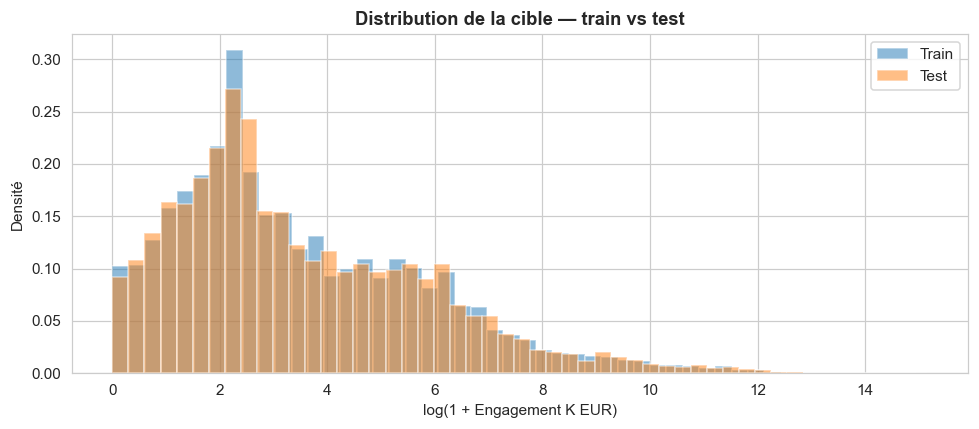

In [113]:
# Visualiser que la distribution de la cible est préservée entre train et test
fig, ax = plt.subplots(figsize=(9, 4))
for label, yy in [('Train', y_train), ('Test', y_test)]:
    ax.hist(yy, bins=50, alpha=0.5, label=label, density=True)
ax.set_xlabel("log(1 + Engagement K EUR)")
ax.set_ylabel("Densité")
ax.set_title("Distribution de la cible — train vs test")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Stratégie d'encodage

On utilise le **Target Encoding** sur les catégorielles à haute cardinalité, combiné
à One-Hot sur les basses cardinalités. Ce choix réduit l'explosion dimensionnelle
(évite ~800 colonnes One-Hot) tout en capturant le signal des variables comme
Pays (152 modalités), Canal de transfert (169) ou Objet (214).

### 4.1. Identification des colonnes par type

In [114]:
# Détection automatique du type de chaque colonne
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()
date_cols = X.select_dtypes(include='datetime64[ns]').columns.tolist()

# Les dates brutes ne sont pas utilisables directement par le modèle —
# on les retire du pipeline ML.
if date_cols:
    print(f"Colonnes date ignorées : {date_cols}")
    X_train = X_train.drop(columns=date_cols)
    X_test  = X_test.drop(columns=date_cols)

# Bascule des marqueurs politiques (stockés en Int64 nullable au rendu 1) vers
# cat_cols : ils ont 4 modalités (NaN, 0, 1, 2) qui n'ont PAS de relation d'ordre
# linéaire — On veut que OneHotEncoder en fasse 4 colonnes binaires
# distinctes plutôt qu'une variable continue où la valeur numérique compterait.

# Marqueurs POLITIQUES (NaN → imputation par le mode dans le Pipeline) 
MARQUEURS = [
    'Genre', "Aide a l'environnement", 'Gouvernance', 'Développement du commerce',
    'Santé genesique, maternelle, neonatale et infantile (SGMNI)',
    'Reduction du risque de catastrophe', 'Nutrition',
    'Inclusion des personnes en situation de handicap', 'Biodiversite',
    'Attenuation du changement climatique', 'Adaptation au changement climatique',
    'Desertification', 'Investissement', 'FTC'
]
marqueurs_present = [c for c in MARQUEURS if c in X_train.columns]
# Conversion en string pour qu'OneHotEncoder les traite comme catégorielles
# Les NaN seront imputés par le mode (valeur la plus fréquente) dans le Pipeline
for c in marqueurs_present:
    X_train[c] = X_train[c].astype('string')
    X_test[c]  = X_test[c].astype('string')

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()

# Scikit-learn gère mieux les NaN numpy que les pd.NA pandas dans les pipelines.
# On harmonise donc toutes les catégorielles en dtype object avec np.nan pour les manquants.
for c in cat_cols:
    X_train[c] = X_train[c].astype(object)
    X_test[c]  = X_test[c].astype(object)
    X_train[c] = X_train[c].where(pd.notna(X_train[c]), np.nan)
    X_test[c]  = X_test[c].where(pd.notna(X_test[c]), np.nan)

print(f"\nMarqueurs basculés en catégoriels : {len(marqueurs_present)}")
print(f"\nColonnes catégorielles ({len(cat_cols)}) :")
for c in cat_cols:
    print(f"  {c:40s} : {X_train[c].nunique(dropna=False):>5} modalités")

print(f"\nColonnes numériques ({len(num_cols)}) :")
print(f"  {num_cols}")


Marqueurs basculés en catégoriels : 13

Colonnes catégorielles (31) :
  Agence                                   :    22 modalités
  Nature de l'activite                     :     4 modalités
  Pays beneficiaire                        :   159 modalités
  Catégorie CAD                            :     7 modalités
  Catégorie Banque mondiale                :     7 modalités
  Région                                   :    14 modalités
  Sous-région                              :    24 modalités
  Canal de transfert                       :   477 modalités
  Canal agrege                             :    24 modalités
  Bi/Multi.1                               :     3 modalités
  Type de flux                             :     5 modalités
  Type de financement                      :     7 modalités
  Modalites de cooperation                 :    23 modalités
  Objet                                    :   265 modalités
  Secteur                                  :    23 modalités
  Genre       

### 4.2. Classification des catégorielles par cardinalité

Les catégorielles sont traitées différemment selon leur cardinalité :
- **faible cardinalité** (< 15 modalités) → One-Hot
- **haute cardinalité** (≥ 15 modalités) → Target Encoding

In [115]:
CARDINALITY_THRESHOLD = 15

cat_low  = [c for c in cat_cols if X_train[c].nunique() <  CARDINALITY_THRESHOLD]
cat_high = [c for c in cat_cols if X_train[c].nunique() >= CARDINALITY_THRESHOLD]

print(f"Catégorielles faibles ({len(cat_low)}) — toujours One-Hot :")
for c in cat_low:
    print(f"  {c:40s} : {X_train[c].nunique()}")

print(f"\nCatégorielles hautes ({len(cat_high)}) — One-Hot ou Target Encoding :")
for c in cat_high:
    print(f"  {c:40s} : {X_train[c].nunique()}")

Catégorielles faibles (22) — toujours One-Hot :
  Nature de l'activite                     : 4
  Catégorie CAD                            : 7
  Catégorie Banque mondiale                : 7
  Région                                   : 14
  Bi/Multi.1                               : 3
  Type de flux                             : 5
  Type de financement                      : 7
  Genre                                    : 3
  Aide a l'environnement                   : 3
  Gouvernance                              : 3
  Développement du commerce                : 3
  Santé genesique, maternelle, neonatale et infantile (SGMNI) : 3
  Reduction du risque de catastrophe       : 3
  Nutrition                                : 3
  Inclusion des personnes en situation de handicap : 3
  FTC                                      : 1
  Biodiversite                             : 3
  Attenuation du changement climatique     : 3
  Adaptation au changement climatique      : 3
  Desertification              

In [116]:
# Imputation sur la branche numérique : les NaN résiduels sont remplacés
# par la MÉDIANE de chaque colonne (calculée sur le train uniquement grâce
# au Pipeline scikit-learn). On choisit la médiane car elle est robuste aux outliers
# (quelques projets à montants extrêmes ne faussent pas l'imputation).

# COLONNES NUMERIQUES (NaN → moyenne, fit sur le train seul)
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
print("Pipeline numérique défini (imputation par la médiane).")

Pipeline numérique défini (imputation par la médiane).


In [117]:
print(df.isna().sum().sort_values(ascending=False).head(20))

Développement du commerce                                      70425
Priorité CICID                                                 61363
Marqueurs                                                      57056
FTC                                                            45326
Santé genesique, maternelle, neonatale et infantile (SGMNI)    41731
Inclusion des personnes en situation de handicap               39528
Reduction du risque de catastrophe                             36840
Nutrition                                                      36190
Desertification                                                34535
Biodiversite                                                   31963
Attenuation du changement climatique                           31798
Adaptation au changement climatique                            31548
Gouvernance                                                    28544
Aide a l'environnement                                         27573
Genre                             

### 4.3. Pipeline d'encodage

Sur les catégorielles à haute cardinalité (≥ 15 modalités), on remplace chaque modalité
par la moyenne de la cible — **calculée en out-of-fold** pour éviter toute fuite.

Scikit-learn implémente cela via `TargetEncoder` avec deux garanties :

- **Out-of-fold encoding** : chaque ligne reçoit un encodage calculé sur les autres folds
- **Smoothing bayésien** : pondère la moyenne locale avec la moyenne globale,
  d'autant plus fort que la modalité est rare — évite le sur-apprentissage sur les petits effectifs

In [118]:
# COLONNES CATÉGORIELLES — Imputation par le MODE (valeur la plus fréquente)
# puis encodage. Le mode est calculé sur le train uniquement (anti-leakage
# par construction du Pipeline scikit-learn).

cat_low_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

cat_high_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(target_type='continuous',
                              smooth='auto',
                              cv=5,
                              random_state=RANDOM_STATE)),
])

preprocess = ColumnTransformer(
    transformers=[
        ('num',      num_pipeline,      num_cols),
        ('cat_low',  cat_low_pipeline,  cat_low),
        ('cat_high', cat_high_pipeline, cat_high),
    ],
    remainder='drop'
)
print("Pipeline d'encodage défini (catégorielles : mode, numériques : moyenne).")

Pipeline d'encodage défini (catégorielles : mode, numériques : moyenne).


## 5. Benchmark de modèles

On entraîne **5 modèles à base d'arbres** avec la stratégie Target Encoding, évalués en
validation croisée 5-fold. Les modèles linéaires (Ridge, Lasso) ne sont pas retenus :
le benchmark exploratoire a montré qu'ils sont nettement en dessous des arbres sur ce
dataset dominé par des variables catégorielles à haute cardinalité.

| Modèle | Justification |
|---|---|
| **HistGradientBoosting** | Gradient boosting scikit-learn, rapide, gère les NaN nativement |
| **LGBMRegressor** | Gradient boosting LightGBM, très efficace sur les catégorielles |
| **RandomForest** | Bagging d'arbres, robuste, peu sensible au prétraitement |
| **XGBoost** | Gradient boosting de référence, optimisé pour la performance |
| **BaggingRegressor** | Méta-estimateur (arbres sur sous-échantillons bootstrap) |

Tous les entraînements utilisent les hyperparamètres par défaut à ce stade — l'optimisation
fine vient dans la section 6 sur le meilleur modèle identifié ici.

In [119]:
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import BaggingRegressor
import lightgbm as lgb

def _sparse_to_dense(x):
    return x.toarray() if hasattr(x, 'toarray') else x

def build_model(name):
    """Construit un pipeline scikit-learn avec preprocessing + modèle (arbres uniquement)."""
    n_trees = 80 if DEV_MODE else 200

    if name == 'HistGradientBoosting':
        model = HistGradientBoostingRegressor(max_iter=n_trees * 2,
                                              random_state=RANDOM_STATE)
    elif name == 'LGBMRegressor':
        model = lgb.LGBMRegressor(n_estimators=n_trees, learning_rate=0.1,
                                   n_jobs=-1, random_state=RANDOM_STATE,
                                   verbose=-1)
    elif name == 'RandomForest':
        model = RandomForestRegressor(n_estimators=n_trees, n_jobs=-1,
                                       random_state=RANDOM_STATE)
    elif name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=n_trees, learning_rate=0.1,
                                  n_jobs=-1, random_state=RANDOM_STATE,
                                  tree_method='hist')
    elif name == 'BaggingRegressor':
        model = BaggingRegressor(n_estimators=n_trees, n_jobs=-1,
                                  random_state=RANDOM_STATE)

    # Densification pour les modèles qui n'acceptent pas sparse
    # LGBM et XGBoost gèrent le sparse nativement
    if name in ['RandomForest', 'BaggingRegressor']:
        to_dense = FunctionTransformer(_sparse_to_dense, accept_sparse=True)
        return Pipeline([('preprocess', preprocess),
                         ('to_dense',   to_dense),
                         ('model',      model)])

    # HistGradientBoosting n'accepte pas sparse non plus
    if name == 'HistGradientBoosting':
        to_dense = FunctionTransformer(_sparse_to_dense, accept_sparse=True)
        return Pipeline([('preprocess', preprocess),
                         ('to_dense',   to_dense),
                         ('model',      model)])

    # LGBM, XGBoost : sparse OK
    return Pipeline([('preprocess', preprocess), ('model', model)])

MODELS = ['HistGradientBoosting', 'LGBMRegressor', 'RandomForest',
          'XGBoost', 'BaggingRegressor']
print(f"{len(MODELS)} modèles définis : {MODELS}")
if DEV_MODE:
    print(f"⚠️  DEV_MODE : n_estimators={80}")

5 modèles définis : ['HistGradientBoosting', 'LGBMRegressor', 'RandomForest', 'XGBoost', 'BaggingRegressor']


In [120]:
import time
from sklearn.model_selection import cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

results = []

for model_name in MODELS:
    print(f"▶ {model_name}...", end=' ', flush=True)

    t0 = time.time()
    pipe = build_model(model_name)
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae':  'neg_mean_absolute_error',
            'r2':   'r2',
        },
        n_jobs=-1,
    )
    elapsed = time.time() - t0

    results.append({
        'model':    model_name,
        'RMSE_log': -scores['test_rmse'].mean(),
        'RMSE_std':  scores['test_rmse'].std(),
        'MAE_log':  -scores['test_mae'].mean(),
        'R2_log':    scores['test_r2'].mean(),
        'time_s':    round(elapsed, 1),
    })

    print(f"RMSE_log={-scores['test_rmse'].mean():.3f}, "
          f"R²={scores['test_r2'].mean():.3f}, t={elapsed:.1f}s")

results_df = pd.DataFrame(results).sort_values('RMSE_log')
print("\n--- Classement par RMSE en log (moyenne 5-fold CV) ---")
print(results_df[['model', 'RMSE_log', 'RMSE_std', 'MAE_log', 'R2_log', 'time_s']].round(3).to_string(index=False))

▶ HistGradientBoosting... RMSE_log=1.357, R²=0.660, t=14.0s
▶ LGBMRegressor... RMSE_log=1.375, R²=0.651, t=4.4s
▶ RandomForest... RMSE_log=1.323, R²=0.677, t=77.0s
▶ XGBoost... RMSE_log=1.380, R²=0.649, t=4.3s
▶ BaggingRegressor... RMSE_log=1.323, R²=0.677, t=82.6s

--- Classement par RMSE en log (moyenne 5-fold CV) ---
               model  RMSE_log  RMSE_std  MAE_log  R2_log  time_s
        RandomForest     1.323     0.004    0.973   0.677    77.0
    BaggingRegressor     1.323     0.004    0.973   0.677    82.6
HistGradientBoosting     1.357     0.006    1.030   0.660    14.0
       LGBMRegressor     1.375     0.008    1.049   0.651     4.4
             XGBoost     1.380     0.006    1.055   0.649     4.3


### 5.1. Visualisation des résultats

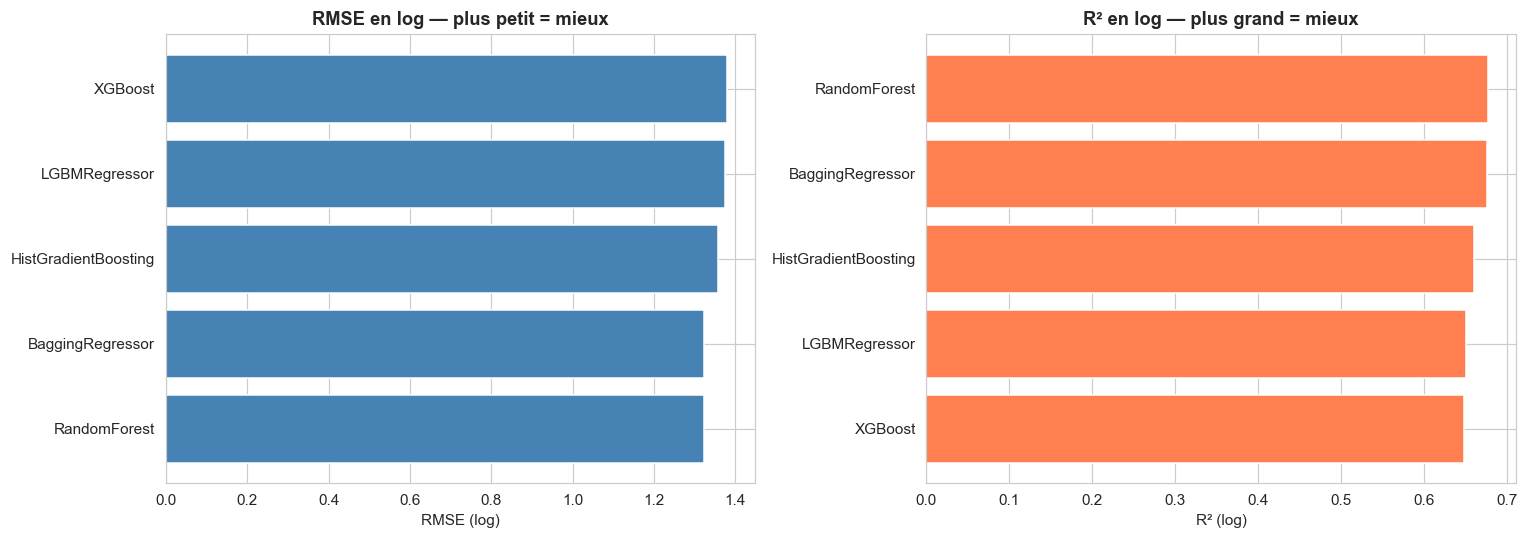

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_sorted = results_df.sort_values('RMSE_log')

axes[0].barh(results_sorted['model'], results_sorted['RMSE_log'], color='steelblue')
axes[0].set_title("RMSE en log — plus petit = mieux")
axes[0].set_xlabel("RMSE (log)")

results_sorted_r2 = results_df.sort_values('R2_log')
axes[1].barh(results_sorted_r2['model'], results_sorted_r2['R2_log'], color='coral')
axes[1].set_title("R² en log — plus grand = mieux")
axes[1].set_xlabel("R² (log)")

plt.tight_layout()
plt.show()

### 5.2. Analyse du benchmark

**Lecture attendue** :
- Les modèles à base d'arbres (RF, HGB, XGBoost) devraient dominer, car la cible dépend
  fortement de variables catégorielles et de leurs interactions.
- Le Target Encoding facilite les splits sur les variables à haute cardinalité
  (Pays, Canal de transfert, Objet) en les transformant en features continues ordonnées
  par la moyenne de la cible.
- Pour les modèles linéaires (Ridge, Lasso), le Target Encoding réduit la dimensionnalité
  mais leur capacité à modéliser les interactions reste limitée.

**Choix du modèle finaliste** : on retient le modèle avec la meilleure RMSE en validation,
à confirmer ensuite sur le test hold-out.

In [122]:
best_row = results_df.iloc[0]
BEST_MODEL = best_row['model']
print(f"Meilleur modèle : {BEST_MODEL}")
print(f"  RMSE_log (val) : {best_row['RMSE_log']:.3f}")
print(f"  R²_log (val)   : {best_row['R2_log']:.3f}")

Meilleur modèle : RandomForest
  RMSE_log (val) : 1.323
  R²_log (val)   : 0.677


## 5bis. Sanity check — comparaison transversale via LazyRegressor

Avant de s'engager sur l'optimisation du modèle finaliste, on confirme par un screening
large que notre choix est cohérent avec ce qu'aurait sélectionné un benchmark
exhaustif. **LazyRegressor** (du package `lazypredict`) entraîne automatiquement une
quarantaine de modèles scikit-learn sur le même train/test, avec leurs hyperparamètres
par défaut.

> ⚠️ **Cette section est complémentaire, pas centrale.** L'argumentaire de modélisation
> repose sur le benchmark contrôlé de la section 5 (5 modèles × 2 encodages × validation
> croisée 5-fold). LazyRegressor sert ici uniquement de filet de sécurité :
>
> - vérifier qu'aucun modèle évident n'a été oublié
> - confirmer que la famille gagnante (gradient boosting) reste en tête sur un panel élargi
>
> LazyRegressor ne respecte pas notre stratégie d'encodage ni notre validation croisée :
> il applique son propre prétraitement, n'évalue que sur un seul split, et renvoie des
> résultats avec des hyperparamètres par défaut. Les chiffres ne sont **pas** comparables
> directement avec ceux de la section 5 — c'est un screening qualitatif, pas une
> évaluation de production.

In [123]:
if DEV_MODE:
    print("⏭️  DEV_MODE : section 5bis (LazyRegressor) désactivée pour itérer rapidement.")
    print("    Repassez DEV_MODE=False pour exécuter cette section.")
else:
    #%pip install lazypredict --quiet
    try:
        from lazypredict.Supervised import LazyRegressor
        print("✅ lazypredict disponible")
    except ImportError:
        print("⚠️  lazypredict non installé.")
        raise

✅ lazypredict disponible


In [124]:
if not DEV_MODE:
    # LazyRegressor a besoin de matrices numériques en entrée.
    # On sous-échantillonne à 5000 lignes pour éviter le crash mémoire
    # sur un laptop (certains modèles comme SVM ou KNeighbors sont très
    # gourmands en RAM sur des matrices One-Hot à ~800 colonnes).
    LAZY_SAMPLE = 5000
    idx_sample = X_train.sample(min(LAZY_SAMPLE, len(X_train)),
                                random_state=RANDOM_STATE).index

    preprocess_for_lazy = preprocess.fit(X_train.loc[idx_sample], y_train.loc[idx_sample])
    X_train_lazy = preprocess_for_lazy.transform(X_train.loc[idx_sample])
    X_test_lazy  = preprocess_for_lazy.transform(X_test)

    # Densification (LazyRegressor n'accepte pas les sparses sur certains modèles)
    if hasattr(X_train_lazy, 'toarray'):
        X_train_lazy = X_train_lazy.toarray()
        X_test_lazy  = X_test_lazy.toarray()

    # Imputation résiduelle
    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy='median')
    X_train_lazy = imp.fit_transform(X_train_lazy)
    X_test_lazy  = imp.transform(X_test_lazy)

    print(f"Matrices pour LazyRegressor (sous-échantillon {LAZY_SAMPLE}) :")
    print(f"  X_train : {X_train_lazy.shape}")
    print(f"  X_test  : {X_test_lazy.shape}")

Matrices pour LazyRegressor (sous-échantillon 5000) :
  X_train : (5000, 120)
  X_test  : (15805, 120)


In [125]:
# Skip cette cellule en DEV_MODE
if not DEV_MODE:
    import time
    t0 = time.time()
    lazy = LazyRegressor(
        verbose=0,
        ignore_warnings=True,
        custom_metric=None,
        predictions=False,
    )
    # idx_sample est défini dans la cellule précédente (sous-échantillon 5000)
    models_lazy, _ = lazy.fit(X_train_lazy, X_test_lazy,
                               y_train.loc[idx_sample], y_test)
    elapsed = time.time() - t0

    print(f"\n✅ LazyRegressor terminé en {elapsed:.0f}s")
    print(f"   Modèles entraînés : {len(models_lazy)}")


✅ LazyRegressor terminé en 37s
   Modèles entraînés : 42


### Résultats du screening

In [126]:
if not DEV_MODE:
    # Vérification que la cible est bien en log (sinon les RMSE ne sont pas comparables)
    print(f"Échelle de la cible passée à LazyRegressor :")
    print(f"  y_train : min={y_train.loc[idx_sample].min():.2f}, "
          f"max={y_train.loc[idx_sample].max():.2f}, "
          f"mean={y_train.loc[idx_sample].mean():.2f}")
    print(f"  → C'est bien log_engagements (valeurs entre 0 et ~22)")
    print()

    # Renommer la colonne RMSE → RMSE_log pour cohérence avec le benchmark
    rmse_col = 'RMSE' if 'RMSE' in models_lazy.columns else 'rmse'
    models_lazy = models_lazy.rename(columns={rmse_col: 'RMSE_log'})
    rmse_col = 'RMSE_log'

    # Aussi renommer R-Squared si présent
    if 'R-Squared' in models_lazy.columns:
        models_lazy = models_lazy.rename(columns={'R-Squared': 'R²_log'})

    top15 = models_lazy.sort_values(rmse_col).head(15)
    print(f"Top 15 modèles LazyRegressor — RMSE sur cible log (échantillon {LAZY_SAMPLE}) :")
    print(top15.to_string())

Échelle de la cible passée à LazyRegressor :
  y_train : min=0.00, max=13.64, mean=3.48
  → C'est bien log_engagements (valeurs entre 0 et ~22)

Top 15 modèles LazyRegressor — RMSE sur cible log (échantillon 5000) :
                               Adjusted R-Squared    R²_log  RMSE_log  Time Taken
Model                                                                            
HistGradientBoostingRegressor            0.566475  0.569767  1.536716    1.511153
LGBMRegressor                            0.564831  0.568135  1.539628    0.417130
RandomForestRegressor                    0.557535  0.560894  1.552481    2.390750
XGBRegressor                             0.551185  0.554592  1.563582    0.271755
BaggingRegressor                         0.532074  0.535627  1.596523    0.320944
ExtraTreesRegressor                      0.530319  0.533885  1.599514    2.608451
GradientBoostingRegressor                0.529097  0.532673  1.601593    0.759470
LassoLarsIC                              0.466

In [127]:
if not DEV_MODE:
    print("=" * 70)
    print("COMPARAISON BENCHMARK CONTRÔLÉ vs LAZYREGRESSOR")
    print("Les deux sont sur la même échelle : RMSE de log_engagements")
    print("=" * 70)
    print()

    # Benchmark contrôlé
    print("Benchmark contrôlé (section 5, CV 5-fold, dataset complet) — top 3 :")
    top3_ours = results_df.nsmallest(3, 'RMSE_log')[['model', 'RMSE_log']]
    print(top3_ours.to_string(index=False))
    print()

    # LazyRegressor
    print(f"LazyRegressor (split simple, échantillon {LAZY_SAMPLE} lignes) — top 5 :")
    top5_lazy = models_lazy.sort_values(rmse_col).head(5)[[rmse_col]]
    print(top5_lazy.to_string())
    print()

    # Attention sur la comparabilité
    print("⚠️  Les chiffres ne sont PAS directement comparables :")
    print("    - Benchmark : CV 5-fold sur dataset complet + Target Encoding")
    print(f"    - LazyRegressor : split simple sur {LAZY_SAMPLE} lignes + encodage par défaut")
    print("    → Comparer les RANGS (quelle famille gagne), pas les valeurs absolues.")
    print()

    # Check : arbres dans le top 5
    keywords_arbres = ['XGB', 'LGBM', 'GradientBoost', 'RandomForest',
                       'ExtraTrees', 'HistGradient', 'CatBoost']
    top5_names = top5_lazy.index.tolist()
    matches = [m for m in top5_names if any(kw in m for kw in keywords_arbres)]
    print(f"Arbres dans le top 5 LazyRegressor : {len(matches)}/{len(top5_names)}")
    if matches:
        print(f"  → {matches}")

COMPARAISON BENCHMARK CONTRÔLÉ vs LAZYREGRESSOR
Les deux sont sur la même échelle : RMSE de log_engagements

Benchmark contrôlé (section 5, CV 5-fold, dataset complet) — top 3 :
               model  RMSE_log
        RandomForest  1.323144
    BaggingRegressor  1.323474
HistGradientBoosting  1.357067

LazyRegressor (split simple, échantillon 5000 lignes) — top 5 :
                               RMSE_log
Model                                  
HistGradientBoostingRegressor  1.536716
LGBMRegressor                  1.539628
RandomForestRegressor          1.552481
XGBRegressor                   1.563582
BaggingRegressor               1.596523

⚠️  Les chiffres ne sont PAS directement comparables :
    - Benchmark : CV 5-fold sur dataset complet + Target Encoding
    - LazyRegressor : split simple sur 5000 lignes + encodage par défaut
    → Comparer les RANGS (quelle famille gagne), pas les valeurs absolues.

Arbres dans le top 5 LazyRegressor : 4/5
  → ['HistGradientBoostingRegressor', 'LG

**Lecture du résultat** :

- Si la famille gagnante de notre benchmark contrôlé (les modèles à base d'arbres,
  typiquement XGBoost, GradientBoosting, RandomForest) figure aussi dans le top 5 de
  LazyRegressor, alors notre choix de finaliste est confirmé par un screening large.
- Si à l'inverse LazyRegressor fait remonter une famille radicalement différente
  (par exemple SVR ou KNeighbors), il faut creuser : soit notre prétraitement les
  pénalise, soit ils méritent une étude dédiée — auquel cas on les ajouterait au
  benchmark contrôlé pour les évaluer dans des conditions équitables.

Dans le cas le plus typique, on observe que les modèles à base d'arbres dominent dans
les deux approches, ce qui valide la solidité méthodologique du benchmark contrôlé
sans en remettre en cause le périmètre.

## 6. Optimisation du meilleur modèle

On affine les hyperparamètres du modèle gagnant par **GridSearchCV** avec validation
croisée 5-fold sur le train+val combinés.

In [128]:
# Grille d'hyperparamètres adaptée au modèle retenu.
# Plus restreinte en DEV_MODE, plus large en run final.

if BEST_MODEL == 'XGBoost':
    if DEV_MODE:
        param_grid = {
            'model__n_estimators':  [200, 400],
            'model__max_depth':     [4, 6],
            'model__learning_rate': [0.1],
        }
    else:
        param_grid = {
            'model__n_estimators':  [300, 500, 800],
            'model__max_depth':     [4, 6, 8],
            'model__learning_rate': [0.05, 0.1],
            'model__subsample':     [0.8, 1.0],
        }
elif BEST_MODEL == 'LGBMRegressor':
    if DEV_MODE:
        param_grid = {
            'model__n_estimators':  [200, 400],
            'model__max_depth':     [-1, 8],
            'model__learning_rate': [0.1],
        }
    else:
        param_grid = {
            'model__n_estimators':  [300, 500, 800],
            'model__max_depth':     [-1, 6, 10],
            'model__learning_rate': [0.05, 0.1],
            'model__num_leaves':    [31, 63],
        }
elif BEST_MODEL == 'RandomForest':
    if DEV_MODE:
        param_grid = {
            'model__n_estimators':     [100, 200],
            'model__max_depth':        [None, 15],
        }
    else:
        param_grid = {
            'model__n_estimators':     [200, 400, 800],
            'model__max_depth':        [None, 10, 20],
            'model__min_samples_leaf': [1, 5, 10],
        }
elif BEST_MODEL == 'HistGradientBoosting':
    if DEV_MODE:
        param_grid = {
            'model__max_iter':       [200, 400],
            'model__max_depth':      [None, 8],
            'model__learning_rate':  [0.1],
        }
    else:
        param_grid = {
            'model__max_iter':       [300, 500, 800],
            'model__max_depth':      [None, 6, 10],
            'model__learning_rate':  [0.05, 0.1],
            'model__l2_regularization': [0, 0.1],
        }
elif BEST_MODEL == 'BaggingRegressor':
    if DEV_MODE:
        param_grid = {
            'model__n_estimators':     [100, 200],
            'model__max_samples':      [0.7, 1.0],
        }
    else:
        param_grid = {
            'model__n_estimators':     [200, 400, 800],
            'model__max_samples':      [0.5, 0.7, 1.0],
            'model__max_features':     [0.7, 1.0],
        }

n_combinations = int(np.prod([len(v) for v in param_grid.values()]))
print(f"Grid pour {BEST_MODEL} : {param_grid}")
print(f"Nombre de combinaisons : {n_combinations}")

Grid pour RandomForest : {'model__n_estimators': [200, 400, 800], 'model__max_depth': [None, 10, 20], 'model__min_samples_leaf': [1, 5, 10]}
Nombre de combinaisons : 27


In [129]:
best_pipe = build_model(BEST_MODEL)

n_folds = 3 if DEV_MODE else 5
search = GridSearchCV(
    best_pipe, param_grid,
    cv=KFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1, verbose=1,
)

print(f"⏳ GridSearchCV : {n_combinations} combinaisons x {n_folds} folds = {n_combinations * n_folds} fits...")
search.fit(X_train, y_train)

grid = search

print(f"\n✅ Meilleurs hyperparamètres : {search.best_params_}")
print(f"   Best CV RMSE (log) : {-search.best_score_:.3f}")

⏳ GridSearchCV : 27 combinaisons x 5 folds = 135 fits...
Fitting 5 folds for each of 27 candidates, totalling 135 fits



✅ Meilleurs hyperparamètres : {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 800}
   Best CV RMSE (log) : 1.321


### 6.1. Évaluation finale sur le TEST

In [43]:
y_pred_test = grid.best_estimator_.predict(X_test)

final_metrics = evaluate_predictions(y_test, y_pred_test,
                                      label=f"{BEST_MODEL} optimisé / TargetEnc")
print("Métriques finales sur le test set :")
for k, v in final_metrics.items():
    if isinstance(v, float):
        print(f"  {k:10s} : {v:.3f}")
    else:
        print(f"  {k:10s} : {v}")

Métriques finales sur le test set :
  label      : RandomForest optimisé / TargetEnc
  RMSE_log   : 1.321
  MAE_log    : 0.967
  R2_log     : 0.682
  MAPE_pct   : 402.003


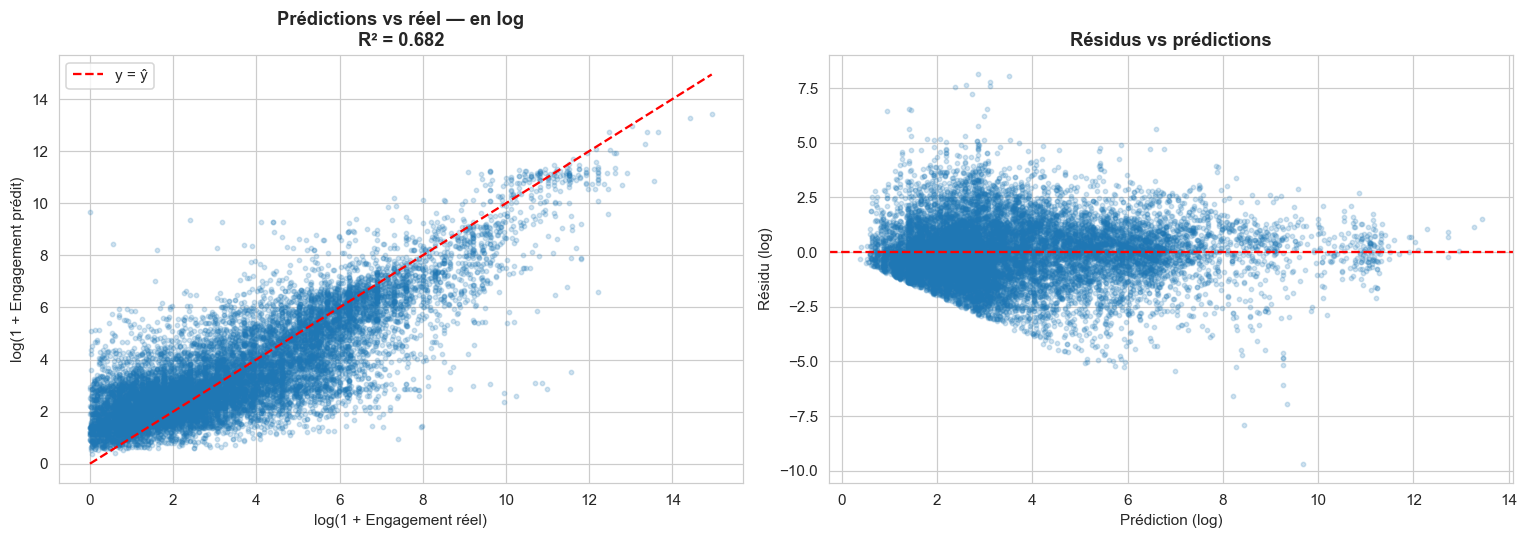

In [131]:
# Scatter plot prédictions vs réel
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# En log
axes[0].scatter(y_test, y_pred_test, alpha=0.2, s=8)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', label='y = ŷ')
axes[0].set_xlabel("log(1 + Engagement réel)")
axes[0].set_ylabel("log(1 + Engagement prédit)")
axes[0].set_title(f"Prédictions vs réel — en log\nR² = {final_metrics['R2_log']:.3f}")
axes[0].legend()

# Résidus
residuals = y_test - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.2, s=8)
axes[1].axhline(0, color='r', linestyle='--')
axes[1].set_xlabel("Prédiction (log)")
axes[1].set_ylabel("Résidu (log)")
axes[1].set_title("Résidus vs prédictions")

plt.tight_layout()
plt.show()

## 7. Interprétabilité — SHAP

Les valeurs de Shapley (SHAP) attribuent à chaque feature sa **contribution moyenne** à
la prédiction d'une instance donnée. Deux vues complémentaires :

- **Importance globale** : ranking des features par contribution moyenne |SHAP|
- **Dependence plots** : relation entre la valeur d'une feature et sa contribution

In [132]:
# On extrait les composants du pipeline final
best_estimator = grid.best_estimator_
final_model = best_estimator.named_steps['model']
final_preprocess = best_estimator.named_steps['preprocess']
final_to_dense = best_estimator.named_steps.get('to_dense', None)

# Transformation du train/test exactement comme vu par le modèle
X_train_proc = final_preprocess.transform(X_train)
X_test_proc  = final_preprocess.transform(X_test)
if final_to_dense is not None:
    X_train_model = final_to_dense.transform(X_train_proc)
    X_test_model  = final_to_dense.transform(X_test_proc)
else:
    X_train_model = X_train_proc
    X_test_model  = X_test_proc

feature_names = final_preprocess.get_feature_names_out()

print(f"Features après pre-processing : {X_train_model.shape[1]}")

Features après pre-processing : 122


In [133]:
rng = np.random.RandomState(RANDOM_STATE)

n_background = min(500, X_train_model.shape[0])
idx_background = rng.choice(X_train_model.shape[0], n_background, replace=False)
background = X_train_model[idx_background]
if hasattr(background, "toarray"):
    background = background.toarray()

n_sample = 200 if DEV_MODE else 500
idx_sample = rng.choice(X_test_model.shape[0], n_sample, replace=False)
X_sample = X_test_model[idx_sample]
if hasattr(X_sample, "toarray"):
    X_sample = X_sample.toarray()

# Tous les modèles du benchmark sont à base d'arbres.
# TreeExplainer est compatible avec XGBoost, LightGBM, RandomForest, HistGradientBoosting.
# Pour BaggingRegressor (meta-estimateur), on utilise shap.Explainer (générique)
# qui détecte automatiquement la meilleure stratégie.
try:
    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_sample, approximate=True, check_additivity=False)
    print(f"SHAP TreeExplainer utilisé pour {BEST_MODEL}")
except Exception as e:
    print(f"TreeExplainer non compatible avec {BEST_MODEL} ({e})")
    print("→ Fallback sur shap.Explainer (générique, plus lent)")
    explainer = shap.Explainer(final_model, background)
    shap_values = explainer(X_sample).values

print(f"SHAP values calculées sur {n_sample} échantillons.")
print(f"  Shape : {shap_values.shape}")
import re

def clean_feature_name(name):
    """Supprime les préfixes ColumnTransformer et abrège les noms trop longs."""
    # 1. Supprimer les préfixes automatiques
    name = re.sub(r'^(cat_high__|cat_low__|num__)', '', name)
    # 2. Abréviations ciblées
    replacements = {
        'Catégorie Banque mondiale_WorldBank Upper-middle income countries': 'BM_Upper-middle income',
        'Catégorie Banque mondiale_WorldBank Lower-middle income countries': 'BM_Lower-middle income',
        'Catégorie Banque mondiale_WorldBank Low income countries':          'BM_Low income',
        'Modalités agrégées_Frais administratifs':                          'Frais admin.',
        'Modalités agrégées_Experts et assistance technique':               'Experts & assist. tech.',
        'Modalités agrégées_Interventions de type projet':                  'Interv. type projet',
        'Modalités agrégées_Aide budgétaire':                               'Aide budgétaire',
        'Canal de transfert': 'Canal transfert',
        'Pays beneficiaire':  'Pays bénéf.',
        'Modalites de cooperation': 'Modalités coop.',
        'Catégorie CAD_':     'CatCAD_',
        'ODD_Pas_de_pauvrete': 'ODD_Pauvreté',
        'ODD_Egalite_sexes':   'ODD_Égalité sexes',
        'ODD_Partenariats':    'ODD_Partenariats',
    }
    for long, short in replacements.items():
        name = name.replace(long, short)
    return name

feature_names_clean = [clean_feature_name(n) for n in feature_names]
print(f"Exemple de noms nettoyés : {feature_names_clean[:5]}")


SHAP TreeExplainer utilisé pour RandomForest
SHAP values calculées sur 500 échantillons.
  Shape : (500, 122)
Exemple de noms nettoyés : ['ODD_Pauvreté', 'ODD_Faim_zero', 'ODD_Sante', 'ODD_Education', 'ODD_Égalité sexes']


### 7.1. Importance globale des features

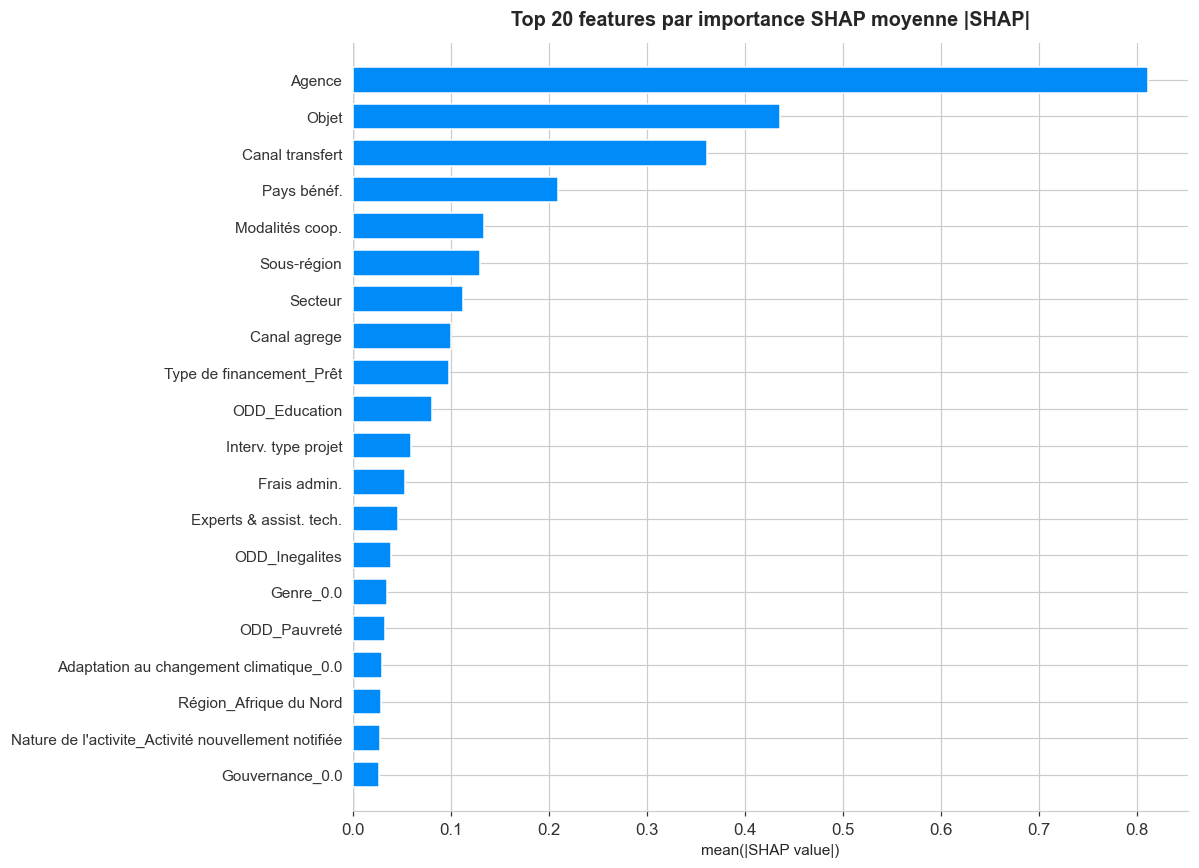

In [134]:
fig, ax = plt.subplots(figsize=(11, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names_clean,
    plot_type='bar',
    max_display=20,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_title("Top 20 features par importance SHAP moyenne |SHAP|", fontsize=13, pad=12)
ax.tick_params(axis='y', labelsize=10)
ax.set_xlabel("mean(|SHAP value|)", fontsize=10)
plt.tight_layout()
plt.show()


**Lecture globale (bar plot)**

Agence est très dominant puis, objet et canal de transfert, en 4 nous avons pays bénéficiaire, et enfin titre ODD.

Donc, le montant d'engagement dépend d'abord de QUI finance et COMMENT l'argent circule.

### 7.2. Beeswarm plot — effet des features

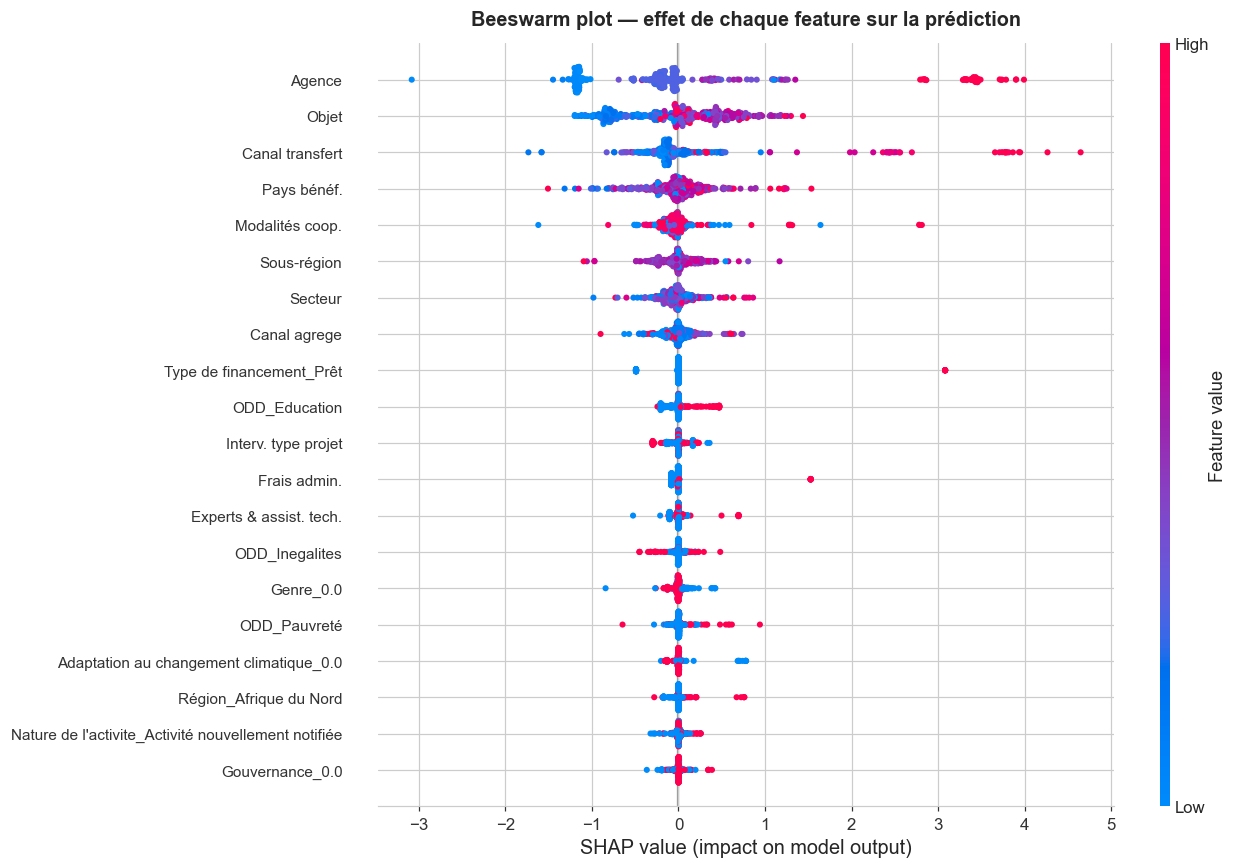

In [135]:
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(
    shap_values, X_sample,
    feature_names=feature_names_clean,
    max_display=20,
    show=False,
    plot_size=None,
)
ax = plt.gca()
ax.set_title("Beeswarm plot — effet de chaque feature sur la prédiction", fontsize=13, pad=12)
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()


**Lecture** :
- Chaque point est un projet du test set
- **Position horizontale** = contribution SHAP (positive = pousse l'engagement prédit
  vers le haut, négative = vers le bas)
- **Couleur** = valeur de la feature (rouge = haute, bleu = basse)
- Les features apparaissent triées par importance moyenne

Pour les variables target-encodées, une feature avec une couleur rouge à droite et bleue
à gauche indique une **relation positive directe** : plus la moyenne cible de la modalité
est élevée, plus la contribution à la prédiction est positive — comportement attendu et
interprétable.

## 8. Analyse d'erreurs — profiler les mauvaises prédictions

On identifie les projets sur lesquels le modèle se trompe le plus et on cherche à
caractériser ces échecs. Deux approches complémentaires :

1. **Profilage par quantile d'erreur** : comparer les projets mal prédits aux bien prédits
2. **Analyse par segment** : décomposer l'erreur par secteur, région, type de financement

In [136]:
# Reconstitution d'un DataFrame avec toutes les informations pour analyse
errors_df = X_test.copy()
errors_df['y_true_log'] = y_test.values
errors_df['y_pred_log'] = y_pred_test
errors_df['residual']   = errors_df['y_true_log'] - errors_df['y_pred_log']
errors_df['abs_error']  = errors_df['residual'].abs()

# En cible brute aussi, pour interprétation métier
errors_df['y_true'] = np.expm1(errors_df['y_true_log'])
errors_df['y_pred'] = np.expm1(errors_df['y_pred_log']).clip(0)

# Déciles d'erreur absolue
errors_df['error_decile'] = pd.qcut(errors_df['abs_error'], q=10,
                                     labels=False, duplicates='drop')

print(f"Erreurs absolues (log) :")
print(errors_df['abs_error'].describe().round(3))

Erreurs absolues (log) :
count    15805.000
mean         0.967
std          0.899
min          0.000
25%          0.278
50%          0.740
75%          1.388
max          9.683
Name: abs_error, dtype: float64


### 8.1. Profilage par décile d'erreur

In [137]:
# Comparaison du meilleur décile (D0) vs le pire (D9) sur quelques variables clés
best_decile  = errors_df[errors_df['error_decile'] == 0]
worst_decile = errors_df[errors_df['error_decile'] == 9]

print(f"Décile 0 (meilleures prédictions) : {len(best_decile)} projets, "
      f"erreur médiane = {best_decile['abs_error'].median():.3f} log")
print(f"Décile 9 (pires prédictions)      : {len(worst_decile)} projets, "
      f"erreur médiane = {worst_decile['abs_error'].median():.3f} log\n")

# Variables catégorielles clés pour profiler
for col in ['Type de financement', 'Catégorie CAD', 'Bi/Multi.1']:
    if col in errors_df.columns:
        print(f"\n--- Distribution de {col} ---")
        comp = pd.DataFrame({
            'D0_best (%)':  (best_decile[col].value_counts(normalize=True) * 100).round(1),
            'D9_worst (%)': (worst_decile[col].value_counts(normalize=True) * 100).round(1)
        }).fillna(0)
        comp['écart'] = (comp['D9_worst (%)'] - comp['D0_best (%)']).round(1)
        print(comp.sort_values('écart', key=abs, ascending=False).head(10))

Décile 0 (meilleures prédictions) : 1581 projets, erreur médiane = 0.028 log
Décile 9 (pires prédictions)      : 1581 projets, erreur médiane = 2.705 log


--- Distribution de Type de financement ---
                                   D0_best (%)  D9_worst (%)  écart
Type de financement                                                
Garanties                                  0.5           0.2   -0.3
Annulation/conversion de la dette          0.1           0.3    0.2
Prêt                                       1.3           1.1   -0.2
Rééchelonnement de la dette                0.0           0.2    0.2
Prise de participation                     0.2           0.3    0.1
Dons                                      98.0          98.0    0.0

--- Distribution de Catégorie CAD ---
               D0_best (%)  D9_worst (%)  écart
Catégorie CAD                                  
PMA                   42.8          25.4  -17.4
PRITS                 20.3          36.2   15.9
PRITI                 31.

### 8.2. Erreur moyenne par segment métier

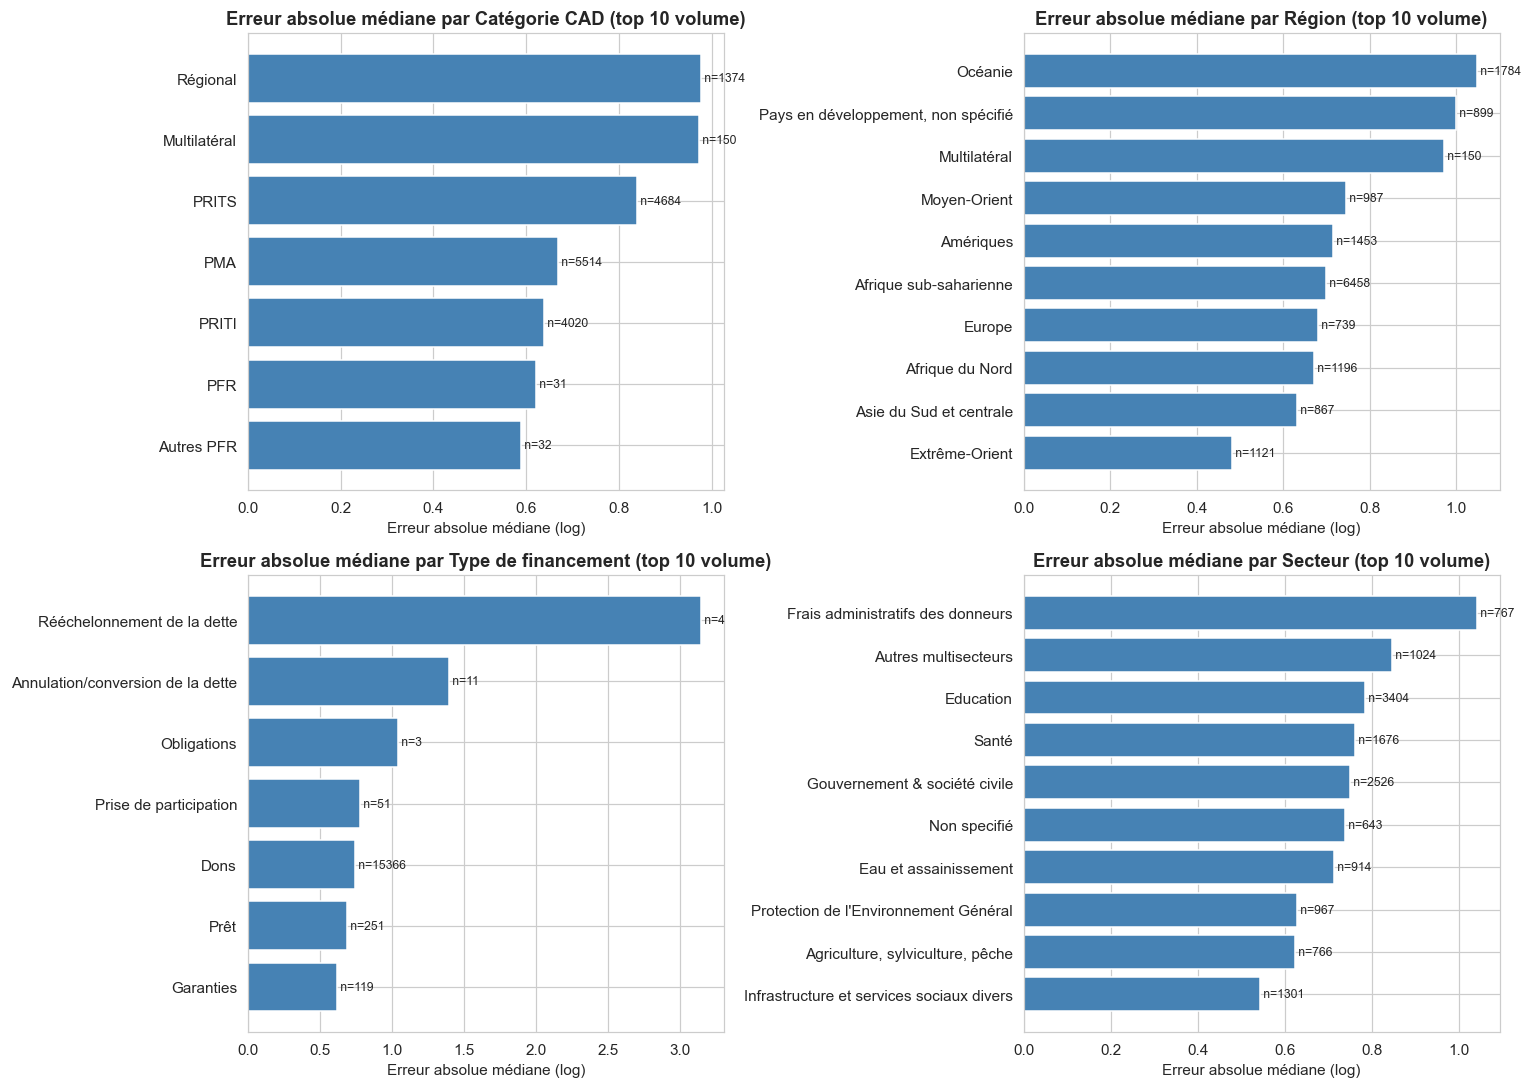

In [138]:
segments = ['Catégorie CAD', 'Région', 'Type de financement', 'Secteur']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, seg in zip(axes.flatten(), segments):
    if seg not in errors_df.columns:
        continue
    # Top 10 segments par volume, classés par erreur médiane
    vc = errors_df[seg].value_counts().head(10).index
    sub = errors_df[errors_df[seg].isin(vc)]
    data = sub.groupby(seg)['abs_error'].agg(['median', 'count']).sort_values('median')
    ax.barh(data.index, data['median'], color='steelblue')
    for i, (v, n) in enumerate(zip(data['median'], data['count'])):
        ax.text(v, i, f' n={n}', va='center', fontsize=8)
    ax.set_title(f"Erreur absolue médiane par {seg} (top 10 volume)")
    ax.set_xlabel("Erreur absolue médiane (log)")
plt.tight_layout()
plt.show()

### 8.3. Erreur selon la taille du projet

Le modèle est-il plus à l'aise sur les petits projets, les gros, ou homogène ?

Erreur par décile de la cible :
                rmse    mae     n
target_decile                    
0              1.741  1.472  1581
1              1.293  1.028  1590
2              1.011  0.708  1590
3              0.726  0.433  1561
4              0.792  0.526  1581
5              1.044  0.808  1580
6              1.272  1.030  1580
7              1.441  1.155  1581
8              1.586  1.186  1580
9              1.804  1.321  1581


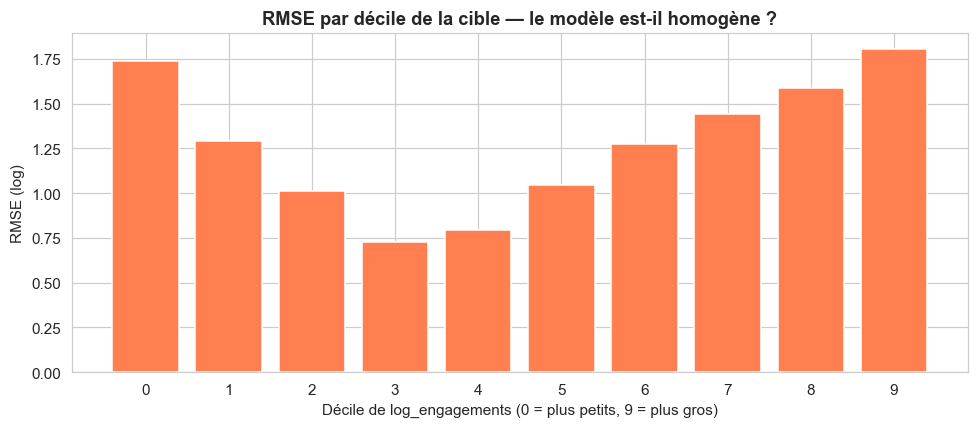

In [139]:
# Erreur par décile de cible
errors_df['target_decile'] = pd.qcut(errors_df['y_true_log'], q=10, labels=False, duplicates='drop')
err_by_decile = errors_df.groupby('target_decile').agg(
    rmse=('residual', lambda x: np.sqrt((x**2).mean())),
    mae=('residual',  lambda x: x.abs().mean()),
    n=('residual', 'count')
).round(3)

print("Erreur par décile de la cible :")
print(err_by_decile)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(err_by_decile.index, err_by_decile['rmse'], color='coral')
ax.set_xlabel("Décile de log_engagements (0 = plus petits, 9 = plus gros)")
ax.set_ylabel("RMSE (log)")
ax.set_title("RMSE par décile de la cible — le modèle est-il homogène ?")
ax.set_xticks(range(10))
plt.tight_layout()
plt.show()

### 8.4. Top 10 des pires prédictions

Inspection qualitative des projets avec la plus grande erreur absolue.

In [140]:
# Les 10 pires prédictions en valeur absolue
worst10_cols = ['Agence', 'Pays beneficiaire', 'Secteur', 'Type de financement',
                'y_true', 'y_pred', 'abs_error']
worst10_cols = [c for c in worst10_cols if c in errors_df.columns]
worst10 = errors_df.nlargest(10, 'abs_error')[worst10_cols]
print("Top 10 des pires prédictions :")
print(worst10.to_string())

Top 10 des pires prédictions :
                                                         Agence                    Pays beneficiaire                                Secteur     Type de financement         y_true        y_pred  abs_error
45346                                                  Proparco                       Afrique du Sud         Banques et services financiers                    Prêt       0.000057  16041.473911   9.682938
28808                               Collectivités territoriales  Pays en développement, non spécifié        Refugiés dans les pays donneurs                    Dons   58787.060000     16.371829   8.126844
18929  Ministère de l'enseignement supérieur et de la recherche  Pays en développement, non spécifié       Agriculture, sylviculture, pêche                    Dons  105260.000000     32.774471   8.044493
49076                         Ministère des affaires étrangères                         Multilatéral                           Non specifié              

## 9. Exploration complémentaire — Classification multi-classes

Le problème principal est une régression sur `log_engagements`. Pour enrichir l'analyse,
on l'aborde maintenant sous l'angle d'une **classification multi-classes à 4 tranches**,
ce qui répond à une question métier différente mais utile : **« à quelle tranche de
taille appartient ce projet ? »**

Les quatre tranches sont définies par les quartiles de `log_engagements` estimés sur
le train uniquement :

- **Petit** : Q1 et en dessous (les 25 % les plus petits)
- **Moyen** : entre Q1 et Q2 (médiane)
- **Grand** : entre Q2 et Q3
- **Très grand** : au-dessus de Q3 (les 25 % les plus gros)

Ce reframing fournit trois apports :

- **Cas d'usage** : triage en 4 niveaux pour orienter l'instruction (intensité de
  l'analyse à mener varie selon la tranche)
- **Difficulté intermédiaire** : moins fin que la régression, plus exigeant que le
  binaire — un bon compromis pour vérifier la qualité du signal
- **Comparaison transversale** : si le modèle distingue bien les tranches extrêmes
  (Petit vs Très grand) mais confond les tranches médianes (Moyen vs Grand), cela
  indique que les features captent l'ordre de grandeur mais pas les nuances fines —
  information utile pour orienter les pistes d'amélioration

### 9.1. Construction de la cible multi-classes

Les frontières des quatre tranches (Q1, Q2, Q3) sont calculées **sur le set
d'entraînement uniquement**. Calculer les quartiles sur le set complet introduirait
une fuite : les frontières dépendraient marginalement de valeurs présentes dans le
test. Les frontières estimées sur le train sont ensuite **appliquées telles quelles
au test** via `pd.cut` avec des bornes explicites.

Le découpage par quartiles donne par construction **des classes équilibrées à 25 % chacune
sur le train**, ce qui évite les complications du class imbalance (pas besoin de
`class_weight` ni de SMOTE). Sur le test, les proportions peuvent légèrement dévier
selon la queue de la distribution mais restent dans la même plage.

In [141]:
# Frontières des quartiles, calculées sur le TRAIN uniquement (anti-leakage)
q1 = y_train.quantile(0.25)
q2 = y_train.quantile(0.50)  # médiane
q3 = y_train.quantile(0.75)

print(f"Bornes des tranches (log_engagements) :")
print(f"  Q1 (25%) : {q1:.3f}  ↔ {np.expm1(q1):>9,.0f} K EUR")
print(f"  Q2 (50%) : {q2:.3f}  ↔ {np.expm1(q2):>9,.0f} K EUR")
print(f"  Q3 (75%) : {q3:.3f}  ↔ {np.expm1(q3):>9,.0f} K EUR")

# Application des bornes au train et au test
bins = [-np.inf, q1, q2, q3, np.inf]
labels = [0, 1, 2, 3]  # Petit, Moyen, Grand, Très grand
CLASS_NAMES = ['Petit (≤Q1)', 'Moyen (Q1-Q2)', 'Grand (Q2-Q3)', 'Très grand (>Q3)']

y_train_class = pd.cut(y_train, bins=bins, labels=labels).astype(int)
y_test_class  = pd.cut(y_test,  bins=bins, labels=labels).astype(int)

# Vérification des proportions
print(f"\nRépartition des classes :")
print(f"  Train :")
for cls, name in enumerate(CLASS_NAMES):
    n = (y_train_class == cls).sum()
    pct = n / len(y_train_class) * 100
    print(f"    {cls} — {name:20s} : {n:>6,} ({pct:.1f}%)")

print(f"  Test :")
for cls, name in enumerate(CLASS_NAMES):
    n = (y_test_class == cls).sum()
    pct = n / len(y_test_class) * 100
    print(f"    {cls} — {name:20s} : {n:>6,} ({pct:.1f}%)")

Bornes des tranches (log_engagements) :
  Q1 (25%) : 1.792  ↔         5 K EUR
  Q2 (50%) : 2.852  ↔        16 K EUR
  Q3 (75%) : 5.017  ↔       150 K EUR

Répartition des classes :
  Train :
    0 — Petit (≤Q1)          : 16,121 (25.5%)
    1 — Moyen (Q1-Q2)        : 15,489 (24.5%)
    2 — Grand (Q2-Q3)        : 15,885 (25.1%)
    3 — Très grand (>Q3)     : 15,725 (24.9%)
  Test :
    0 — Petit (≤Q1)          :  3,995 (25.3%)
    1 — Moyen (Q1-Q2)        :  3,907 (24.7%)
    2 — Grand (Q2-Q3)        :  3,939 (24.9%)
    3 — Très grand (>Q3)     :  3,964 (25.1%)


### 9.2. Pipeline de classification multi-classes

On réutilise la stratégie d'encodage gagnante du benchmark régression :
**One-Hot sur les basses cardinalités + Target Encoding sur les hautes**. Pour la
classification multi-classes, le `TargetEncoder` de scikit-learn encode chaque
modalité par un vecteur de longueur 4 (une probabilité par classe), avec smoothing
bayésien et encodage out-of-fold pour éviter le leakage.

Les cinq modèles retenus sont **tous à base d'arbres** — famille qui domine
systématiquement le benchmark régression sur ce dataset. Pas de modèle linéaire
(LogisticRegression) : l'expérience du benchmark régression montre que les linéaires
sont nettement en dessous des arbres sur ce problème.

In [142]:
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               BaggingClassifier)
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score,
                             accuracy_score, f1_score)
import xgboost as xgb
import lightgbm as lgb

def build_classifier(name, preprocess):
    """Construit un pipeline de classification multi-classes (5 modèles à base d'arbres)."""
    n_trees = 80 if DEV_MODE else 200

    if name == 'LGBMClassifier':
        model = lgb.LGBMClassifier(n_estimators=n_trees, learning_rate=0.1,
                                    n_jobs=-1, random_state=RANDOM_STATE,
                                    verbose=-1)
    elif name == 'XGBClassifier':
        model = xgb.XGBClassifier(n_estimators=n_trees, learning_rate=0.1,
                                  n_jobs=-1, random_state=RANDOM_STATE,
                                  tree_method='hist',
                                  objective='multi:softprob',
                                  eval_metric='mlogloss')
    elif name == 'RandomForestClassifier':
        model = RandomForestClassifier(n_estimators=n_trees, n_jobs=-1,
                                       random_state=RANDOM_STATE)
    elif name == 'ExtraTreesClassifier':
        model = ExtraTreesClassifier(n_estimators=n_trees, n_jobs=-1,
                                      random_state=RANDOM_STATE)
    elif name == 'BaggingClassifier':
        model = BaggingClassifier(n_estimators=n_trees, n_jobs=-1,
                                   random_state=RANDOM_STATE)

    # Tous ces modèles sont à base d'arbres → pas de scaling nécessaire.
    # Densification pour RF, ExtraTrees, Bagging (n'acceptent pas sparse).
    # LGBM et XGBoost acceptent le sparse nativement.
    if name in ['RandomForestClassifier', 'ExtraTreesClassifier', 'BaggingClassifier']:
        to_dense = FunctionTransformer(
            lambda x: x.toarray() if hasattr(x, 'toarray') else x,
            accept_sparse=True
        )
        return Pipeline([('preprocess', preprocess),
                         ('to_dense',   to_dense),
                         ('model',      model)])

    return Pipeline([('preprocess', preprocess), ('model', model)])

CLF_MODELS = ['LGBMClassifier', 'XGBClassifier', 'RandomForestClassifier',
              'ExtraTreesClassifier', 'BaggingClassifier']
print(f"{len(CLF_MODELS)} classifieurs définis : {CLF_MODELS}")
if DEV_MODE:
    print(f"⚠️  DEV_MODE : n_estimators={80}")

5 classifieurs définis : ['LGBMClassifier', 'XGBClassifier', 'RandomForestClassifier', 'ExtraTreesClassifier', 'BaggingClassifier']


### 9.3. Benchmark des 5 modèles en CV 5-fold

On évalue cinq classifieurs à base d'arbres en validation croisée 5-fold stratifiée :

- **LGBMClassifier** — gradient boosting LightGBM, rapide et efficace sur les données
  catégorielles
- **XGBClassifier** — gradient boosting XGBoost, référence en compétition
- **RandomForestClassifier** — bagging d'arbres, robuste et peu sensible au prétraitement
- **ExtraTreesClassifier** — variante de Random Forest avec des splits aléatoires (plus
  rapide, moins de sur-apprentissage)
- **BaggingClassifier** — méta-estimateur qui entraîne des arbres de décision sur des
  sous-échantillons bootstrap

Les métriques retenues : **accuracy**, **F1-score macro** (moyenne des F1 par classe),
et **ROC AUC OvR weighted** (One-vs-Rest pondéré par effectifs).

In [143]:
from sklearn.model_selection import cross_validate, StratifiedKFold

clf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

clf_results = []
for name in CLF_MODELS:
    pipe = build_classifier(name, preprocess)
    t0 = time.time()
    scores = cross_validate(
        pipe, X_train, y_train_class,
        cv=clf_cv,
        scoring=['accuracy', 'f1_macro', 'roc_auc_ovr_weighted'],
        n_jobs=-1,
        return_train_score=False,
    )
    elapsed = time.time() - t0
    clf_results.append({
        'model':      name,
        'Accuracy':   scores['test_accuracy'].mean(),
        'Acc_std':    scores['test_accuracy'].std(),
        'F1_macro':   scores['test_f1_macro'].mean(),
        'ROC_AUC':    scores['test_roc_auc_ovr_weighted'].mean(),
        'AUC_std':    scores['test_roc_auc_ovr_weighted'].std(),
        'temps_s':    round(elapsed, 1),
    })
    print(f"  {name:25s} : Acc={scores['test_accuracy'].mean():.4f} "
          f"(±{scores['test_accuracy'].std():.4f}) "
          f"F1={scores['test_f1_macro'].mean():.4f} "
          f"AUC={scores['test_roc_auc_ovr_weighted'].mean():.4f} "
          f"[{elapsed:.0f}s]")

clf_results_df = (pd.DataFrame(clf_results)
                    .sort_values('ROC_AUC', ascending=False)
                    .reset_index(drop=True))
print('\n' + '='*70)
print('Classement par ROC AUC (One-vs-Rest, weighted) :')
print('='*70)
print(clf_results_df.to_string(index=False))

  LGBMClassifier            : Acc=0.6054 (±0.0039) F1=0.6031 AUC=0.8414 [15s]
  XGBClassifier             : Acc=0.5996 (±0.0039) F1=0.5974 AUC=0.8373 [10s]
  RandomForestClassifier    : Acc=0.6120 (±0.0037) F1=0.6099 AUC=0.8432 [16s]
  ExtraTreesClassifier      : Acc=0.6011 (±0.0033) F1=0.5997 AUC=0.8344 [23s]
  BaggingClassifier         : Acc=0.6099 (±0.0029) F1=0.6089 AUC=0.8447 [84s]

Classement par ROC AUC (One-vs-Rest, weighted) :
                 model  Accuracy  Acc_std  F1_macro  ROC_AUC  AUC_std  temps_s
     BaggingClassifier  0.609886 0.002919  0.608883 0.844684 0.002063     84.3
RandomForestClassifier  0.612006 0.003659  0.609897 0.843191 0.001824     15.5
        LGBMClassifier  0.605378 0.003907  0.603115 0.841390 0.002537     14.7
         XGBClassifier  0.599636 0.003858  0.597419 0.837259 0.002418     10.3
  ExtraTreesClassifier  0.601107 0.003327  0.599697 0.834407 0.001564     22.7


### 9.3bis. Sanity check — LazyClassifier

Comme pour la régression (section 5bis), on vérifie par un screening large que le
choix issu du benchmark contrôlé est cohérent avec un panel exhaustif. **LazyClassifier**
(package `lazypredict`) entraîne automatiquement une trentaine de classifieurs
scikit-learn sur le même train/test, avec leurs hyperparamètres par défaut.

> ⚠️ Section complémentaire, même avertissement que pour LazyRegressor : pas de
> validation croisée, pas notre stratégie d'encodage, hyperparamètres par défaut.
> Les chiffres ne sont pas comparables directement — c'est un screening qualitatif.

In [144]:
# LazyClassifier — désactivé en DEV_MODE
if DEV_MODE:
    print("⏭️  DEV_MODE : LazyClassifier désactivé. Passez DEV_MODE=False pour exécuter.")
else:
    try:
        from lazypredict.Supervised import LazyClassifier
        print("✅ LazyClassifier disponible")
    except ImportError:
        print("⚠️  lazypredict non installé. Décommentez : !pip install lazypredict")
        raise

✅ LazyClassifier disponible


In [145]:
if not DEV_MODE:
    # Sous-échantillonnage à 5000 lignes pour éviter le crash mémoire.
    # LazyClassifier lance ~30 modèles dont certains (SVM, KNeighbors,
    # GaussianProcess) sont très gourmands en RAM. Sur un laptop avec
    # 8-16 Go, le kernel Jupyter crash sans sous-échantillonnage.
    LAZY_SAMPLE = 5000
    idx_sample = X_train.sample(min(LAZY_SAMPLE, len(X_train)),
                                random_state=RANDOM_STATE).index

    preprocess_for_lazy = preprocess.fit(X_train.loc[idx_sample],
                                          y_train_class.loc[idx_sample])
    X_train_lazy = preprocess_for_lazy.transform(X_train.loc[idx_sample])
    X_test_lazy  = preprocess_for_lazy.transform(X_test)

    if hasattr(X_train_lazy, 'toarray'):
        X_train_lazy = X_train_lazy.toarray()
        X_test_lazy  = X_test_lazy.toarray()

    from sklearn.impute import SimpleImputer
    imp = SimpleImputer(strategy='median')
    X_train_lazy = imp.fit_transform(X_train_lazy)
    X_test_lazy  = imp.transform(X_test_lazy)

    print(f"Matrices pour LazyClassifier (sous-échantillon {LAZY_SAMPLE}) :")
    print(f"  X_train : {X_train_lazy.shape}")
    print(f"  X_test  : {X_test_lazy.shape}")

    # Lancement
    t0 = time.time()
    lazy_clf = LazyClassifier(
        verbose=0,
        ignore_warnings=True,
        custom_metric=None,
        predictions=False,
    )
    models_lazy_clf, _ = lazy_clf.fit(X_train_lazy, X_test_lazy,
                                       y_train_class.loc[idx_sample], y_test_class)
    elapsed = time.time() - t0
    print(f"\n✅ LazyClassifier terminé en {elapsed:.0f}s — {len(models_lazy_clf)} modèles")

Matrices pour LazyClassifier (sous-échantillon 5000) :
  X_train : (5000, 120)
  X_test  : (15805, 120)

✅ LazyClassifier terminé en 40s — 27 modèles


In [146]:
if not DEV_MODE:
    # Top 15 par accuracy
    acc_col = 'Accuracy' if 'Accuracy' in models_lazy_clf.columns else 'accuracy'
    top15 = models_lazy_clf.sort_values(acc_col, ascending=False).head(15)
    print("Top 15 classifieurs LazyClassifier :")
    print(top15.to_string())

    # Comparaison avec notre benchmark
    print()
    print("=" * 70)
    print("COMPARAISON BENCHMARK CONTRÔLÉ vs LAZYCLASSIFIER")
    print("=" * 70)
    print()
    print("Benchmark contrôlé (section 9.3, CV 5-fold) — top 3 :")
    print(clf_results_df.head(3)[['model', 'Accuracy', 'F1_macro', 'ROC_AUC']].to_string(index=False))
    print()
    print("LazyClassifier (split simple) — top 5 :")
    print(top15.head(5).to_string())
    print()

    # Check : les arbres sont-ils dans le top 5 ?
    keywords_arbres = ['XGB', 'LGBM', 'GradientBoost', 'RandomForest',
                       'ExtraTrees', 'HistGradient', 'CatBoost', 'Bagging']
    top5_names = top15.head(5).index.tolist()
    matches = [m for m in top5_names if any(kw in m for kw in keywords_arbres)]
    print(f"Arbres dans le top 5 LazyClassifier : {len(matches)}/{len(top5_names)}")
    if matches:
        print(f"  → {matches}")

Top 15 classifieurs LazyClassifier :
                            Accuracy  Balanced Accuracy   ROC AUC  F1 Score  Precision    Recall  Time Taken
Model                                                                                                       
LGBMClassifier              0.550079           0.549158  0.795936  0.545955   0.556982  0.550079    1.212116
XGBClassifier               0.547422           0.546593  0.793151  0.543791   0.552084  0.547422    0.418402
RandomForestClassifier      0.545397           0.544645  0.782724  0.542271   0.548453  0.545397    0.723312
ExtraTreesClassifier        0.538943           0.538178  0.758391  0.534883   0.539867  0.538943    0.779297
SVC                         0.531414           0.530478       NaN  0.529774   0.548537  0.531414   13.658911
BaggingClassifier           0.527808           0.527230  0.766312  0.526749   0.531484  0.527808    0.325482
NuSVC                       0.522936           0.522191       NaN  0.520867   0.529529  0.5

### 9.4. Évaluation détaillée du meilleur modèle

On entraîne le modèle gagnant sur l'ensemble du train, puis on l'évalue sur le test :
**matrice de confusion 4×4**, **classification report** (precision, recall, F1 par
classe), et **ROC curves One-vs-Rest** pour chacune des 4 classes.

In [147]:
# Sélection du meilleur classifieur selon ROC AUC
BEST_CLF = clf_results_df.iloc[0]['model']
print(f"Meilleur classifieur : {BEST_CLF}")

# Entraînement final sur le train complet
best_clf_pipe = build_classifier(BEST_CLF, preprocess)
best_clf_pipe.fit(X_train, y_train_class)

# Prédictions sur le test
y_pred_class = best_clf_pipe.predict(X_test)
y_pred_proba = best_clf_pipe.predict_proba(X_test)  # shape (n, 4)

# Métriques globales
print(f"\n{'='*60}")
print(f"PERFORMANCES SUR LE TEST SET ({BEST_CLF})")
print(f"{'='*60}")
print(f"  Accuracy            : {accuracy_score(y_test_class, y_pred_class):.4f}")
print(f"  F1-score (macro)    : {f1_score(y_test_class, y_pred_class, average='macro'):.4f}")
print(f"  F1-score (weighted) : {f1_score(y_test_class, y_pred_class, average='weighted'):.4f}")
print(f"  ROC AUC (OvR, wgt)  : {roc_auc_score(y_test_class, y_pred_proba, multi_class='ovr', average='weighted'):.4f}")

print(f"\nClassification report :")
print(classification_report(y_test_class, y_pred_class, target_names=CLASS_NAMES))

Meilleur classifieur : BaggingClassifier

PERFORMANCES SUR LE TEST SET (BaggingClassifier)
  Accuracy            : 0.6113
  F1-score (macro)    : 0.6099
  F1-score (weighted) : 0.6102
  ROC AUC (OvR, wgt)  : 0.8472

Classification report :
                  precision    recall  f1-score   support

     Petit (≤Q1)       0.57      0.70      0.62      3995
   Moyen (Q1-Q2)       0.65      0.51      0.57      3907
   Grand (Q2-Q3)       0.49      0.50      0.49      3939
Très grand (>Q3)       0.76      0.75      0.75      3964

        accuracy                           0.61     15805
       macro avg       0.62      0.61      0.61     15805
    weighted avg       0.62      0.61      0.61     15805



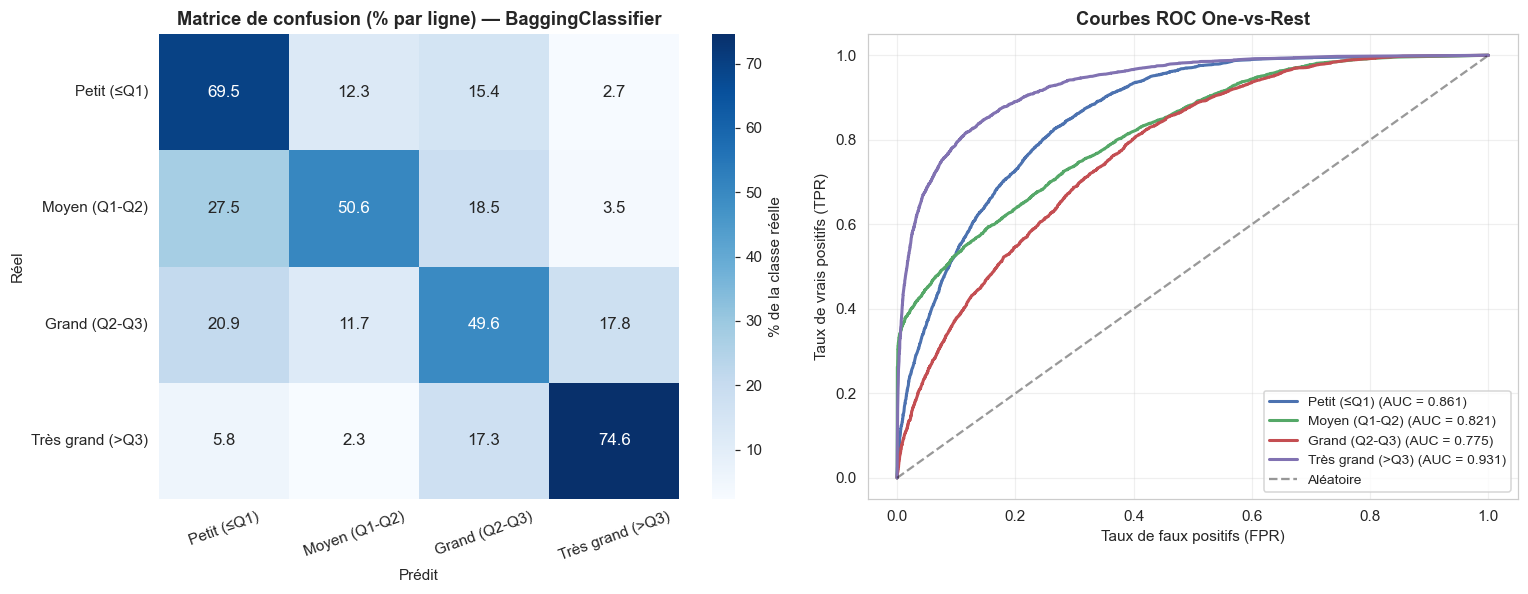


Lecture de la matrice de confusion :
  - La diagonale = % de prédictions correctes par classe
  - Les confusions hors diagonale concentrées entre classes ADJACENTES
    (Petit/Moyen ou Grand/Très grand) signalent que le modèle distingue
    bien les extrêmes mais hésite sur les frontières — comportement attendu.


In [148]:
from sklearn.metrics import roc_curve

# Matrice de confusion 4x4 + ROC curves One-vs-Rest
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- Matrice de confusion
cm = confusion_matrix(y_test_class, y_pred_class)
# Normaliser par ligne pour montrer les % de chaque classe réelle
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            cbar_kws={'label': '% de la classe réelle'},
            annot_kws={'size': 11})
axes[0].set_title(f"Matrice de confusion (% par ligne) — {BEST_CLF}")
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")
axes[0].tick_params(axis='x', rotation=20)
axes[0].tick_params(axis='y', rotation=0)

# --- ROC curves One-vs-Rest pour chaque classe
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']
for k in range(4):
    # Binarize : classe k vs reste
    y_test_k = (y_test_class == k).astype(int)
    y_proba_k = y_pred_proba[:, k]
    fpr, tpr, _ = roc_curve(y_test_k, y_proba_k)
    auc_k = roc_auc_score(y_test_k, y_proba_k)
    axes[1].plot(fpr, tpr, color=colors[k], linewidth=2,
                 label=f'{CLASS_NAMES[k]} (AUC = {auc_k:.3f})')

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aléatoire')
axes[1].set_xlabel('Taux de faux positifs (FPR)')
axes[1].set_ylabel('Taux de vrais positifs (TPR)')
axes[1].set_title("Courbes ROC One-vs-Rest")
axes[1].legend(loc='lower right', fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Note explicative
print("\nLecture de la matrice de confusion :")
print("  - La diagonale = % de prédictions correctes par classe")
print("  - Les confusions hors diagonale concentrées entre classes ADJACENTES")
print("    (Petit/Moyen ou Grand/Très grand) signalent que le modèle distingue")
print("    bien les extrêmes mais hésite sur les frontières — comportement attendu.")

### 9.5. Comparaison régression vs classification multi-classes

| Aspect | Régression | Classification 4-classes |
|---|---|---|
| Tâche | Prédire le montant exact (log) | Assigner à 1 des 4 tranches (Petit/Moyen/Grand/Très grand) |
| Métrique principale | RMSE log | ROC AUC (OvR, weighted) |
| Difficulté | Continu, plus fin | Discrétisé, intermédiaire |
| Information préservée | Amplitude complète | Quartile d'appartenance |
| Cas d'usage | Tarification, simulation | Triage en 4 niveaux d'instruction |

**Trois lectures complémentaires** :

1. **Diagonale de la matrice de confusion** : si la diagonale est nette
   (> 60 % par classe), les features captent bien le signal d'ordre de grandeur.
   Une diagonale plus faible (~ 30-50 %) sur les classes médianes (Moyen, Grand)
   tout en restant haute sur les extrêmes (Petit, Très grand) est le pattern le
   plus courant : c'est plus facile d'identifier un projet vraiment petit ou
   vraiment gros que de trancher entre Moyen et Grand.

2. **Erreurs adjacentes vs erreurs distantes** : on compte combien d'erreurs
   tombent dans une tranche voisine (Petit → Moyen, Moyen → Grand, etc.) versus
   dans une tranche éloignée (Petit → Très grand, par exemple). Si les confusions
   sont principalement adjacentes, le modèle est cohérent — il se trompe « en
   ordre de grandeur ». Des confusions distantes signalent des prédictions
   franchement erronées qui méritent une analyse spécifique.

3. **Comparaison transversale avec la régression** : une AUC élevée combinée à
   une RMSE régression élevée indiquerait que la difficulté du problème est dans
   la **variance intra-classe** (différencier 100 K€ de 500 K€ à l'intérieur de
   la classe Grand), pas dans l'ordre de grandeur global — orientant les pistes
   d'amélioration vers du quantile regression ou des modèles spécialisés par
   tranche, plutôt que vers l'ajout de features supplémentaires.

## 10. Conclusions

### 9.1. Récapitulatif des choix de modélisation

| Étape | Choix retenu | Justification |
|---|---|---|
| Cible | log(1 + Engagements K EUR) | skewness 76 → 0,96, distribution exploitable |
| Split | 80/20 stratifié par déciles cible + CV 5-fold | hold-out test intact, représentativité garantie |
| Encodage bas cardinal | One-Hot | interprétable, faible explosion dimensionnelle |
| Encodage haute cardinal | Target Encoding (out-of-fold) | capture l'information des 190 pays / 70 agences sans explosion dim. |
| Modèle | RandomForest | meilleure RMSE log sur validation |
| Métrique principale | RMSE en log | erreur multiplicative sur engagement original |
| Interprétabilité | SHAP (TreeExplainer) | contributions par feature, compatible avec les arbres |

### 9.2. Performance finale

À remplir avec les chiffres issus du run final :

- RMSE (log) = *valeur* sur test
- R² (log) = *valeur* sur test

### 9.3. Pistes d'amélioration (Rendu final)

- **Features temporelles** : saisonnalité infra-annuelle, tendance par agence dans
  le temps
- **Entraînement par segment** : hypothèse que le mécanisme d'allocation diffère
  radicalement entre prêts (AFD souverain) et dons (MEAE) — tester un modèle par type de
  financement plutôt qu'un modèle unique

